# Pattern #1: Reflection — Agents That Think

**LangGraph Implementation**

## Overview

The Reflection pattern implements self-critique and iterative improvement as a **cyclic graph**:

```
START → draft → critique → assess ─┬─ (sufficient) → END
                   ↑                │
                   └── revise ←─────┘  (needs improvement)
```

LangGraph gives us:
- **Typed state** tracking draft, critique, and iteration count
- **Conditional edges** for the assess → revise-or-stop decision
- **Cycles** for the critique → revise → critique loop

**No tools or RAG** — pure agent cognition and self-improvement.

In [ ]:
import sys
import operator
sys.path.append('..')

from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from IPython.display import Image, display

from utils import create_llm_provider, get_config


def show_graph(runnable):
    """Render the LangGraph graph as a Mermaid diagram."""
    try:
        display(Image(runnable.get_graph().draw_mermaid_png()))
    except Exception:
        print(runnable.get_graph().draw_mermaid())


config = get_config()
llm = create_llm_provider()

print(f"Using model: {config.get('model')}")
print(f"Temperature: {config.get('temperature')}")

Using model: openai/gpt-4o-mini
Temperature: 0.2


## Project Structure

All notebooks in this repo share a set of utility modules in the parent directory:

| Module | Purpose |
|---|---|
| `utils/` | LLM provider factory (`create_llm_provider`), config loader (`get_config`), token counter |
| `rag_internal/` | Internal RAG retriever backed by Qdrant — represents *agent memory*, not a tool |
| `tools/` | External tools: `web_search` (Tavily) and `booking_tool` (local JSON lookup) |
| `config/` | `models.yaml` and `params.yaml` — provider, model, and RAG settings |
| `data/` | Medical knowledge `.txt` files for RAG and `bookings.json` for the booking tool |

This notebook uses only `utils/` — the Reflection pattern is pure LLM cognition with no tools or RAG.

### Validation

In [ ]:
assert config.get("model"), "config.get('model') should be set"
assert llm is not None, "create_llm_provider() should return a provider"
print("\u2713 Setup valid: config and LLM ready.")

✓ Setup valid: config and LLM ready.


## Step 1: Define the State

The reflection state tracks everything the loop needs:
- The user query (immutable input)
- The current draft, critique, and revision (updated each iteration)
- A revision history — every revised draft is appended using `Annotated[list, operator.add]`
- Whether the quality is sufficient (controls the loop exit)
- Iteration counters and token usage (metrics)

In [ ]:
class ReflectionState(TypedDict):
    query: str
    current_draft: str
    critique: str
    revision_history: Annotated[list, operator.add]  # appends each revised draft
    is_sufficient: bool
    iteration: int
    max_iterations: int
    total_tokens: int

## Step 2: Define the Nodes

Each node is a function that takes state, calls the LLM, and returns a partial state update.

| Node | Purpose |
|---|---|
| `draft_node` | Generate initial response |
| `critique_node` | Critically evaluate current draft |
| `assess_node` | Decide if draft quality is sufficient |
| `revise_node` | Improve draft based on critique |

In [ ]:
def draft_node(state: ReflectionState) -> dict:
    """Generate initial draft response."""
    print(f"\n{'=' * 70}")
    print("NODE: draft")
    print(f"{'=' * 70}")

    response = llm.generate(
        prompt=state["query"],
        system_prompt=(
            "You are a helpful healthcare assistant providing information about "
            "preparing for medical visits. Generate a clear, helpful response. "
            "Focus on practical advice and common preparation steps."
        ),
    )

    print(f"\n{response['response'][:300]}...")
    print(f"\n[Tokens: {response['total_tokens']}, Latency: {response['latency_ms']}ms]")

    return {
        "current_draft": response["response"],
        "total_tokens": state["total_tokens"] + response["total_tokens"],
    }


def critique_node(state: ReflectionState) -> dict:
    """Critique the current draft."""
    iteration = state["iteration"] + 1

    print(f"\n{'=' * 70}")
    print(f"NODE: critique (iteration {iteration}/{state['max_iterations']})")
    print(f"{'=' * 70}")

    response = llm.generate(
        prompt=(
            f"Original Question: {state['query']}\n\n"
            f"Draft Response: {state['current_draft']}\n\n"
            f"Please provide a critical review with specific improvement suggestions."
        ),
        system_prompt=(
            "You are a critical reviewer evaluating healthcare information responses. "
            "Review the draft and provide constructive feedback on: "
            "1. Completeness 2. Accuracy 3. Clarity 4. Actionability 5. Safety. "
            "Provide specific suggestions for improvement."
        ),
    )

    print(f"\n{response['response'][:300]}...")
    print(f"\n[Tokens: {response['total_tokens']}, Latency: {response['latency_ms']}ms]")

    return {
        "critique": response["response"],
        "iteration": iteration,
        "total_tokens": state["total_tokens"] + response["total_tokens"],
    }


def assess_node(state: ReflectionState) -> dict:
    """Use LLM to assess whether the critique indicates sufficient quality."""
    print(f"\n{'─' * 70}")
    print("NODE: assess")
    print(f"{'─' * 70}")

    if state["iteration"] > state["max_iterations"]:
        print(f"Max iterations ({state['max_iterations']}) reached — stopping.")
        return {"is_sufficient": True}

    response = llm.generate(
        prompt=(
            f"Original question: {state['query']}\n\n"
            f"Draft response (excerpt): {state['current_draft'][:500]}\n\n"
            f"Critique: {state['critique']}\n\n"
            f"Is the draft already sufficient based on this critique? "
            f"Use SUFFICIENT and REASONING as specified."
        ),
        system_prompt=(
            "You are an evaluator judging whether a critique indicates the draft is "
            "already of sufficient quality and needs no further revision.\n\n"
            "Respond in exactly this format (no other text):\n"
            "SUFFICIENT: YES or NO\n"
            "REASONING: <one short sentence>"
        ),
    )

    text = response["response"].strip().upper()
    sufficient = "SUFFICIENT: YES" in text or "SUFFICIENT:YES" in text

    reasoning = ""
    if "REASONING:" in response["response"]:
        reasoning = response["response"].split("REASONING:")[-1].strip().split("\n")[0]

    print(f"Sufficient: {sufficient}")
    print(f"Reasoning:  {reasoning}")

    return {
        "is_sufficient": sufficient,
        "total_tokens": state["total_tokens"] + response["total_tokens"],
    }


def revise_node(state: ReflectionState) -> dict:
    """Revise draft based on critique."""
    print(f"\n{'=' * 70}")
    print(f"NODE: revise (iteration {state['iteration']})")
    print(f"{'=' * 70}")

    response = llm.generate(
        prompt=(
            f"Original Question: {state['query']}\n\n"
            f"Your Draft: {state['current_draft']}\n\n"
            f"Critique Feedback: {state['critique']}\n\n"
            f"Please provide an improved response that addresses all feedback points."
        ),
        system_prompt=(
            "You are a healthcare assistant revising your response based on feedback. "
            "Improve your draft by addressing all critique points. "
            'Always end with: "This is educational information; verify with the hospital / consult your clinician."'
        ),
    )

    print(f"\n{response['response'][:300]}...")
    print(f"\n[Tokens: {response['total_tokens']}, Latency: {response['latency_ms']}ms]")

    return {
        "current_draft": response["response"],
        "revision_history": [response["response"]],  # Annotated[list] appends across iterations
        "total_tokens": state["total_tokens"] + response["total_tokens"],
    }

## Step 3: Build the Graph

The conditional edge after `assess` is the key — it either exits (sufficient) or loops back through `revise → critique`.

```
START → draft → critique → assess ─┬─ "sufficient" → END
                   ↑                │
                   └── revise ←─────┘  "needs_improvement"
```

Reflection graph compiled ✓


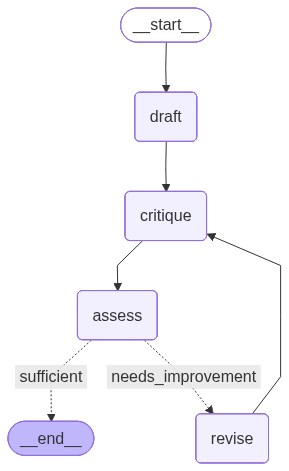

In [ ]:
def should_continue(state: ReflectionState) -> str:
    """Routing function: stop or continue the loop."""
    if state["is_sufficient"]:
        return "sufficient"
    return "needs_improvement"


graph = StateGraph(ReflectionState)

graph.add_node("draft", draft_node)
graph.add_node("critique", critique_node)
graph.add_node("assess", assess_node)
graph.add_node("revise", revise_node)

graph.add_edge(START, "draft")
graph.add_edge("draft", "critique")
graph.add_edge("critique", "assess")
graph.add_conditional_edges("assess", should_continue, {
    "sufficient": END,
    "needs_improvement": "revise",
})
graph.add_edge("revise", "critique")

reflection_app = graph.compile()
print("Reflection graph compiled \u2713")

show_graph(reflection_app)

## Example 1: Single Iteration

With `max_iterations=1`, the graph runs: **draft → critique → assess → (revise or stop)**

The `assess` node evaluates the critique using the LLM. If quality is sufficient it exits; otherwise it revises once, then stops after the second critique (max hit). This mirrors the from-scratch behaviour where `max_iterations=1` always attempts a revision.

In [ ]:
result = reflection_app.invoke({
    "query": "How should I prepare for a dermatology OPD visit?",
    "current_draft": "",
    "critique": "",
    "revision_history": [],
    "is_sufficient": False,
    "iteration": 0,
    "max_iterations": 1,
    "total_tokens": 0,
})

print(f"\n{'=' * 70}")
print("FINAL ANSWER")
print(f"{'=' * 70}")
print(result["current_draft"])
print(f"\nTotal tokens:     {result['total_tokens']}")
print(f"Iterations:       {result['iteration']}")
print(f"Revisions made:   {len(result['revision_history'])}")


NODE: draft

Preparing for a dermatology outpatient department (OPD) visit can help ensure that you get the most out of your appointment. Here are some practical steps to follow:

1. **Gather Your Medical History**:
   - Write down any relevant medical history, including previous skin conditions, treatments, and...

[Tokens: 454, Latency: 7458ms]

NODE: critique (iteration 1/1)

**Critical Review of Draft Response:**

1. **Completeness**: 
   - The response covers several important aspects of preparing for a dermatology visit, but it could benefit from additional details. For instance, it could include information about what to expect during the visit, such as common proced...

[Tokens: 1001, Latency: 9338ms]

──────────────────────────────────────────────────────────────────────
NODE: assess
──────────────────────────────────────────────────────────────────────
Sufficient: False
Reasoning:  The critique identifies several areas for improvement, including completeness, clarity, and sa

## Example 2: Multi-Iteration with Early Stopping

With `max_iterations=3`, the graph can loop up to 3 times through critique → revise.

The `assess` node uses the LLM to decide whether the critique indicates sufficient quality.
If yes, the loop exits early — no wasted iterations.

In [ ]:
result = reflection_app.invoke({
    "query": "What precautions should I take before blood tests?",
    "current_draft": "",
    "critique": "",
    "revision_history": [],
    "is_sufficient": False,
    "iteration": 0,
    "max_iterations": 3,
    "total_tokens": 0,
})

print(f"\n{'=' * 70}")
print("FINAL ANSWER")
print(f"{'=' * 70}")
print(result["current_draft"])
print(f"\nTotal tokens:     {result['total_tokens']}")
print(f"Iterations:       {result['iteration']}")
print(f"Revisions made:   {len(result['revision_history'])}")
print(f"Stopped early:    {result['iteration'] < result['max_iterations']}")


NODE: draft

Preparing for blood tests is important to ensure accurate results. Here are some practical steps you can take:

1. **Follow Fasting Instructions**: If your doctor has advised you to fast before the test, make sure to do so. This usually means no food or drink (except water) for 8-12 hours before the...

[Tokens: 415, Latency: 6548ms]

NODE: critique (iteration 1/3)

**Critical Review of Draft Response:**

1. **Completeness**: 
   - The response covers many essential precautions but could benefit from additional details. For instance, it could mention specific types of blood tests that may have unique preparation requirements (e.g., lipid panels, glucose tests)....

[Tokens: 962, Latency: 8913ms]

──────────────────────────────────────────────────────────────────────
NODE: assess
──────────────────────────────────────────────────────────────────────
Sufficient: False
Reasoning:  The critique highlights several areas for improvement, including completeness, clarity, and saf

## Pattern Summary

### LangGraph vs From-Scratch

| Aspect | From-Scratch | LangGraph |
|---|---|---|
| Control flow | Manual `for` loop + `if/break` | Graph with conditional edges + cycles |
| State | Dict passed between functions | Typed `ReflectionState` managed by graph |
| Loop logic | `for i in range(max_iterations)` | `revise → critique` edge + routing function |
| Early stopping | `break` inside loop | Conditional edge routes to `END` |

### Benefits of LangGraph

- **Declarative** — the graph *shows* the workflow, no need to trace `for` loops
- **Typed state** — `ReflectionState` enforces what data exists at each step
- **Composable** — this reflection graph can be a subgraph inside a larger system
- **Observable** — LangGraph can trace, checkpoint, and visualize each step

### Graph Structure

```
START → draft → critique → assess ─┬─ END
                   ↑                │
                   └── revise ←─────┘
```